# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Clean Gym Fitness Dataset](https://www.kaggle.com/datasets/aryanmdev/world-gym-and-fitness-trends-20002026?select=clean_gym_data.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('clean_gym_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.0,0.2219
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.0,0.2192
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.0,0.2164
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.0,0.2137
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.0,0.2110


## last Five row

In [4]:
df.tail()

,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
3559,Zimbabwe,2022,Africa,296579.0,0.3563,17794742.0,455.0,0.0185,0.3871,0.1243,2536.4005,16069056.0,5.0,0.177
3560,Zimbabwe,2023,Africa,297002.0,0.3589,17820123.0,475.0,0.0182,0.3929,0.1243,2195.2249,16340822.0,5.0,0.177
3561,Zimbabwe,2024,Africa,329254.0,0.3616,19755223.0,508.0,0.0198,0.3989,0.1243,2497.2033,16634373.0,5.0,0.177
3562,Zimbabwe,2025,Africa,332112.0,0.3616,19926723.0,512.0,0.0200,0.3989,0.1243,2497.2033,16634373.0,5.0,0.177
3563,Zimbabwe,2026,Africa,334559.0,0.3616,20073561.0,516.0,0.0201,0.3989,0.1243,2497.2033,16634373.0,5.0,0.177


## Shape of our dataset

In [5]:
df.shape

(3564, 14)

## List out all columns

In [6]:
df.columns

Index(['country', 'year', 'region', 'gym_memberships',
       'fitness_participation_rate', 'total_health_club_revenue_usd',
       'number_of_gyms', 'gym_penetration_rate', 'urban_population_percentage',
       'obesity_rate', 'gdp_per_capita_usd', 'population_total',
       'average_membership_cost_usd', 'insufficient_physical_activity_pct'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

country                                object
year                                    int64
region                                 object
gym_memberships                       float64
fitness_participation_rate            float64
total_health_club_revenue_usd         float64
number_of_gyms                        float64
gym_penetration_rate                  float64
urban_population_percentage           float64
obesity_rate                          float64
gdp_per_capita_usd                    float64
population_total                      float64
average_membership_cost_usd           float64
insufficient_physical_activity_pct    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3564 entries, 0 to 3563
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   country                             3564 non-null   object 
 1   year                                3564 non-null   int64  
 2   region                              3564 non-null   object 
 3   gym_memberships                     3564 non-null   float64
 4   fitness_participation_rate          3564 non-null   float64
 5   total_health_club_revenue_usd       3564 non-null   float64
 6   number_of_gyms                      3564 non-null   float64
 7   gym_penetration_rate                3564 non-null   float64
 8   urban_population_percentage         3564 non-null   float64
 9   obesity_rate                        3564 non-null   float64
 10  gdp_per_capita_usd                  3564 non-null   float64
 11  population_total                    3564 no

## Check Null Value

In [9]:
df.isnull().sum()

country                               0
year                                  0
region                                0
gym_memberships                       0
fitness_participation_rate            0
total_health_club_revenue_usd         0
number_of_gyms                        0
gym_penetration_rate                  0
urban_population_percentage           0
obesity_rate                          0
gdp_per_capita_usd                    0
population_total                      0
average_membership_cost_usd           0
insufficient_physical_activity_pct    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,year,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
count,3564.000000,3.564000e+03,3564.000000,3.564000e+03,3564.000000,3564.000000,3564.000000,3564.000000,3564.000000,3.564000e+03,3564.000000,3564.000000
mean,2013.000000,2.376142e+06,0.397892,6.034040e+08,2076.547138,0.067213,0.610007,0.187892,15615.268427,5.185536e+07,14.371563,0.272071
std,7.789974,7.129730e+06,0.087345,2.981056e+09,5227.710072,0.057984,0.219071,0.104702,21272.389671,1.657860e+08,14.064816,0.118444
min,2000.000000,2.051000e+03,0.204700,1.648750e+05,3.000000,0.002300,0.116400,0.002800,109.593800,1.816850e+05,5.000000,0.027000
25%,2006.000000,1.628528e+05,0.333100,1.533129e+07,205.000000,0.019600,0.463475,0.102975,2011.057500,4.467102e+06,5.060000,0.188000
50%,2013.000000,5.108880e+05,0.399900,5.568824e+07,556.000000,0.052200,0.633950,0.196100,5830.212650,1.210349e+07,8.055000,0.250100
75%,2020.000000,1.560638e+06,0.453750,2.737641e+08,1580.750000,0.099500,0.784175,0.259400,21455.622900,3.803110e+07,17.792500,0.345025
max,2026.000000,1.027881e+08,0.675800,8.486183e+10,62233.000000,0.302200,1.000000,0.612400,137781.681700,1.450936e+09,90.920000,0.661400


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

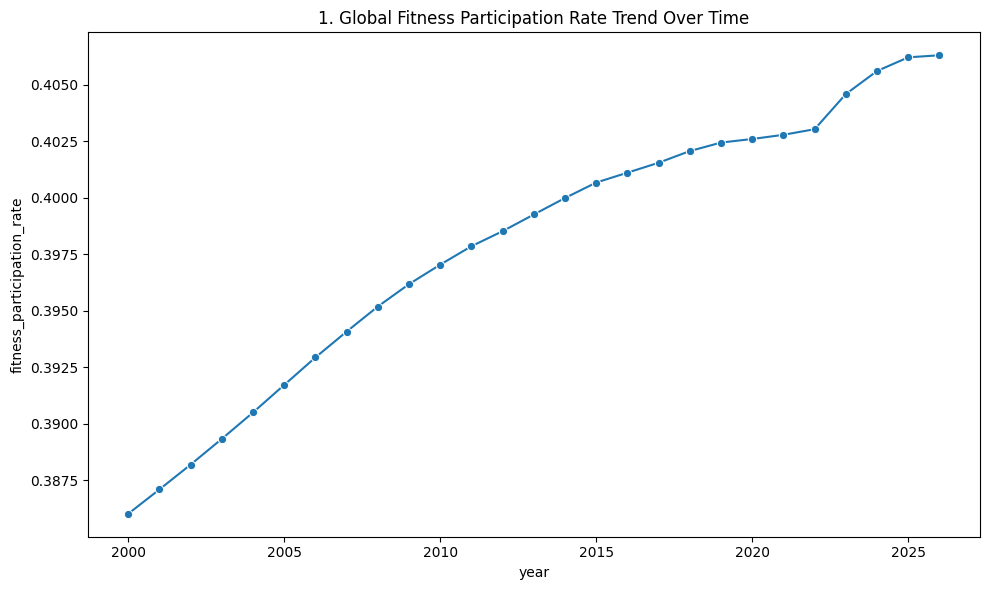

In [13]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='fitness_participation_rate', estimator='mean', errorbar=None, marker='o')
plt.title(f'{plot_no}. Global Fitness Participation Rate Trend Over Time')
show_fig()
plot_no += 1

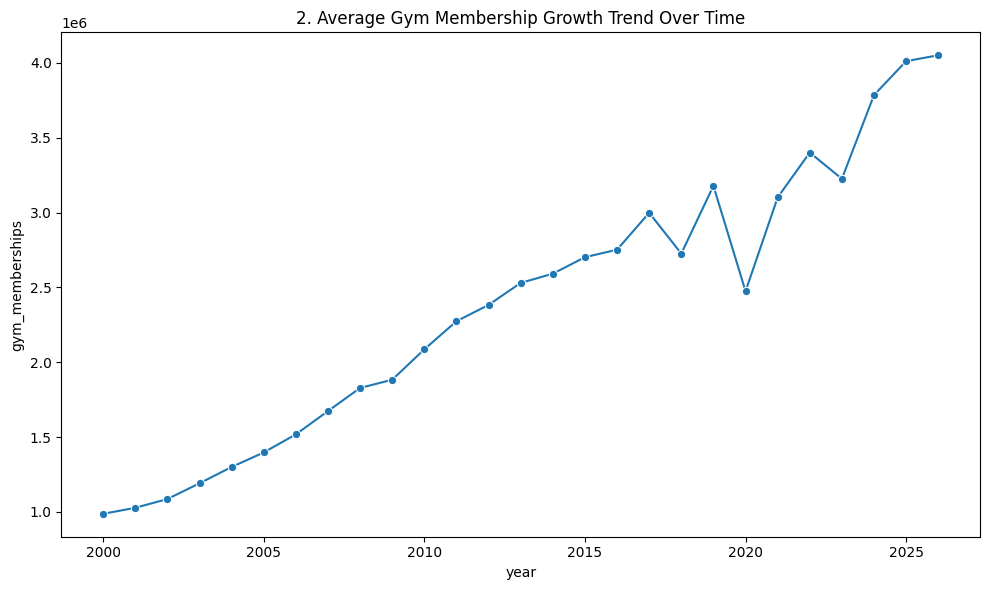

In [14]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='gym_memberships', estimator='mean', errorbar=None, marker='o')
plt.title(f'{plot_no}. Average Gym Membership Growth Trend Over Time')
show_fig()
plot_no += 1

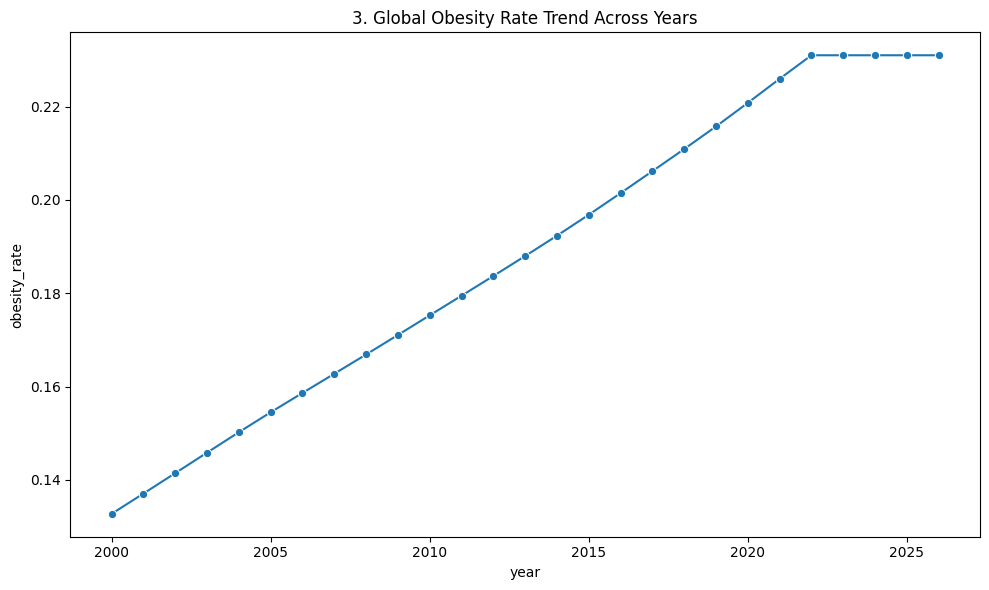

In [15]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='obesity_rate', estimator='mean', errorbar=None, marker='o')
plt.title(f'{plot_no}. Global Obesity Rate Trend Across Years')
show_fig()
plot_no += 1

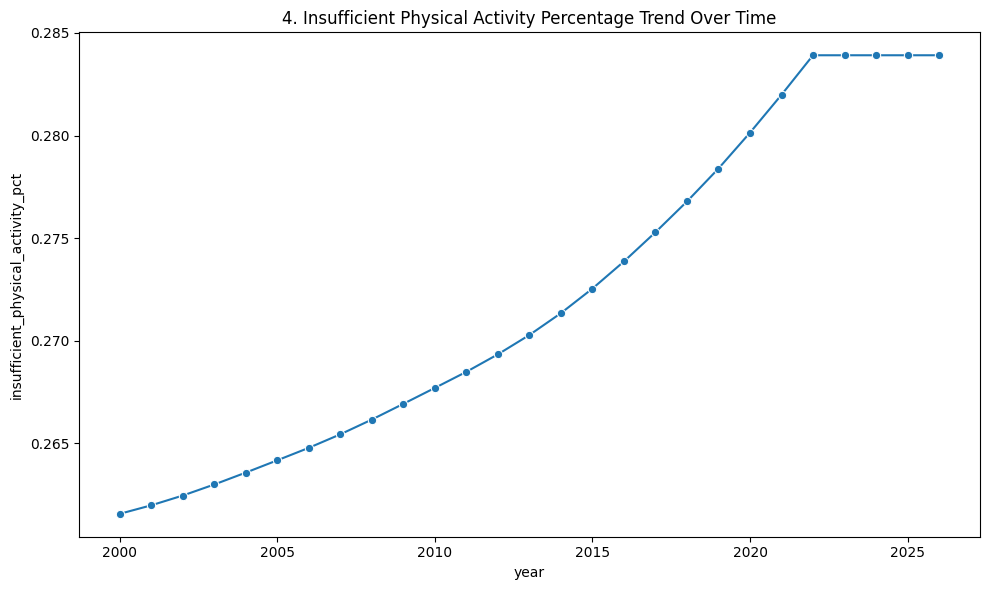

In [16]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='year', y='insufficient_physical_activity_pct', estimator='mean', errorbar=None, marker='o')
plt.title(f'{plot_no}. Insufficient Physical Activity Percentage Trend Over Time')
show_fig()
plot_no += 1

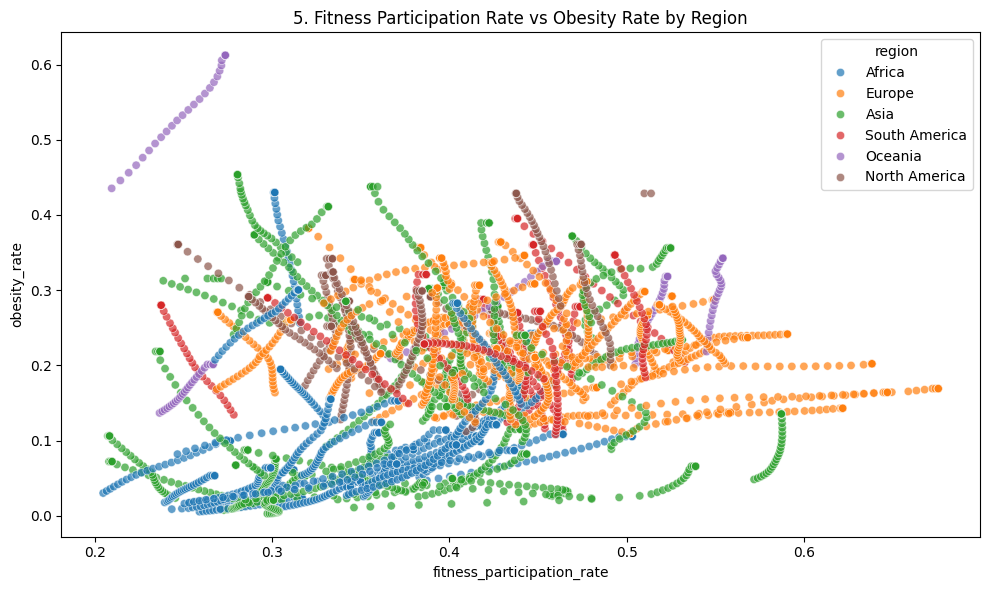

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='fitness_participation_rate', y='obesity_rate', hue='region', alpha=0.7)
plt.title(f'{plot_no}. Fitness Participation Rate vs Obesity Rate by Region')
show_fig()
plot_no += 1

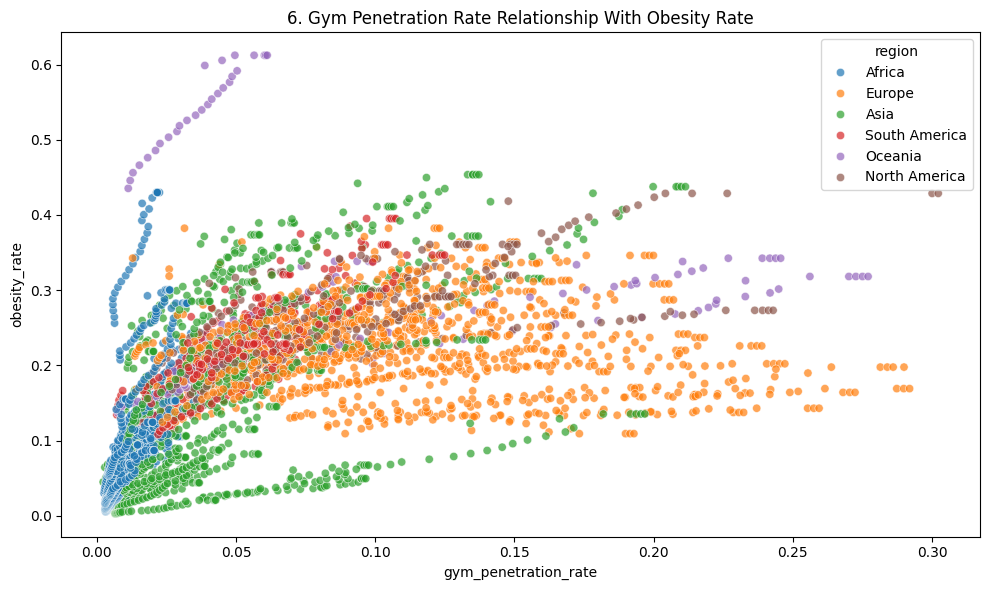

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gym_penetration_rate', y='obesity_rate', hue='region', alpha=0.7)
plt.title(f'{plot_no}. Gym Penetration Rate Relationship With Obesity Rate')
show_fig()
plot_no += 1

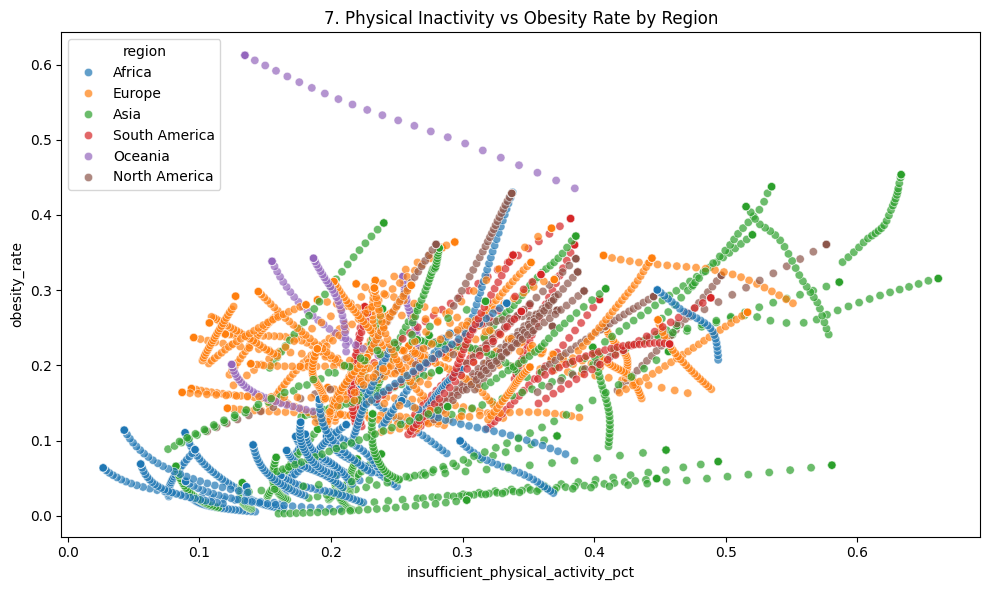

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='insufficient_physical_activity_pct', y='obesity_rate', hue='region', alpha=0.7)
plt.title(f'{plot_no}. Physical Inactivity vs Obesity Rate by Region')
show_fig()
plot_no += 1

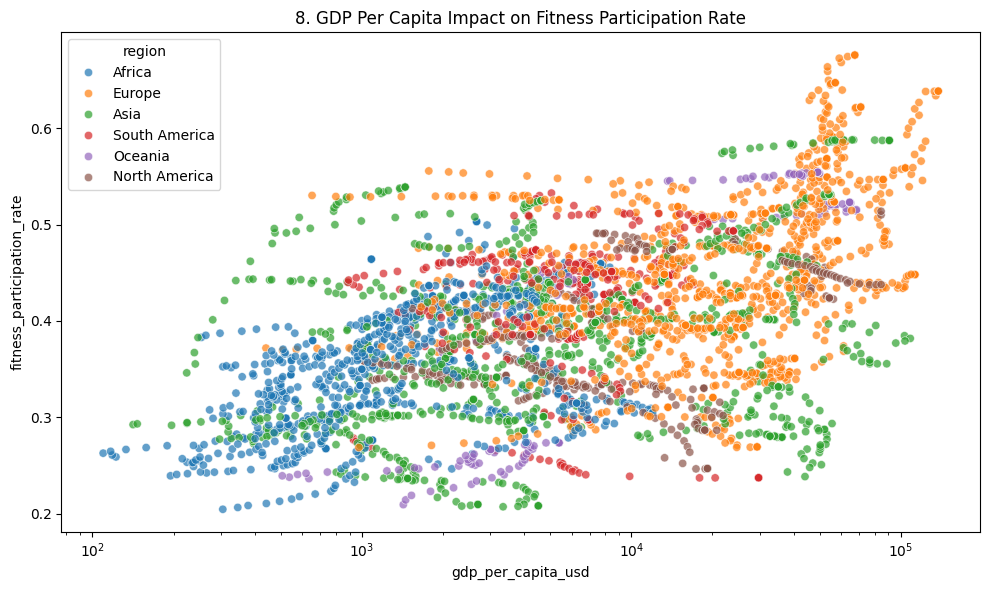

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gdp_per_capita_usd', y='fitness_participation_rate', hue='region', alpha=0.7)
plt.xscale('log')
plt.title(f'{plot_no}. GDP Per Capita Impact on Fitness Participation Rate')
show_fig()
plot_no += 1

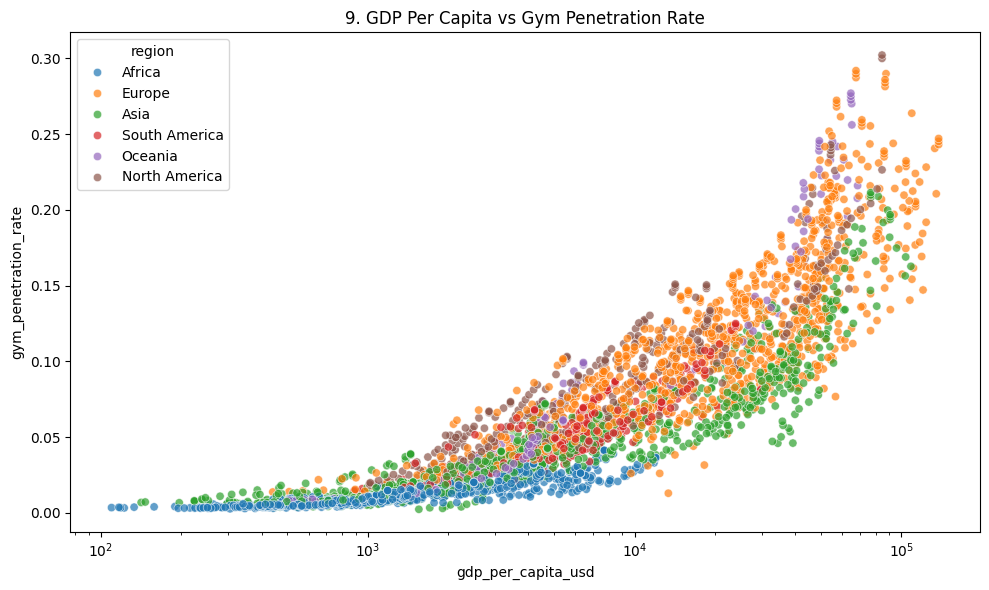

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='gdp_per_capita_usd', y='gym_penetration_rate', hue='region', alpha=0.7)
plt.xscale('log')
plt.title(f'{plot_no}. GDP Per Capita vs Gym Penetration Rate')
show_fig()
plot_no += 1

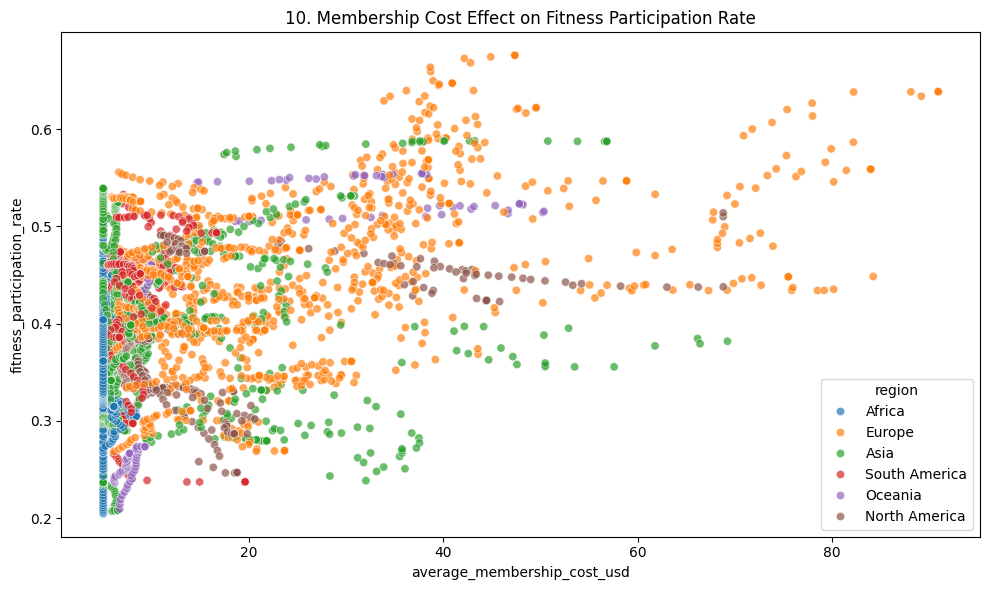

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='average_membership_cost_usd', y='fitness_participation_rate', hue='region', alpha=0.7)
plt.title(f'{plot_no}. Membership Cost Effect on Fitness Participation Rate')
show_fig()
plot_no += 1

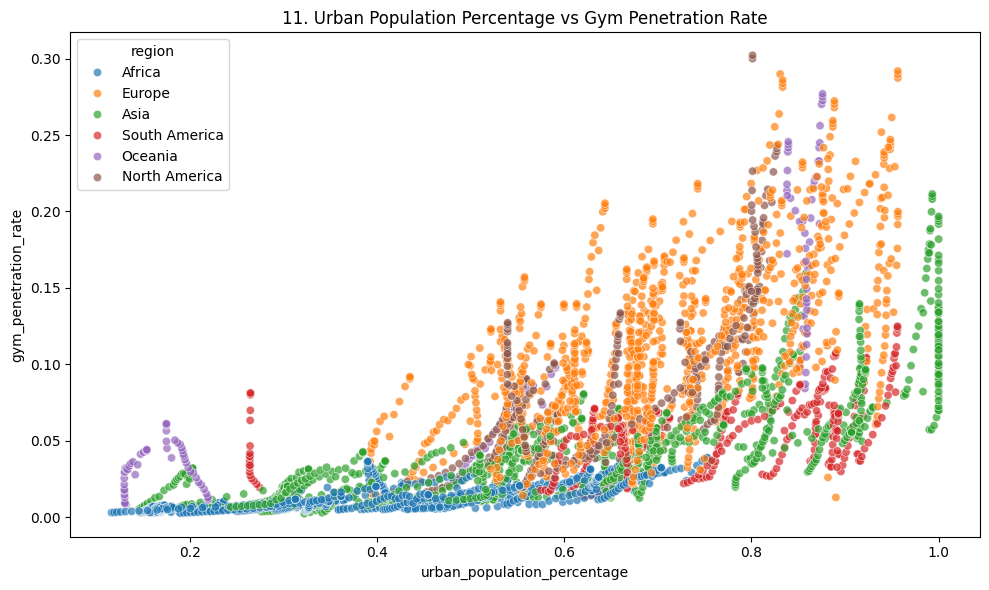

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='urban_population_percentage', y='gym_penetration_rate', hue='region', alpha=0.7)
plt.title(f'{plot_no}. Urban Population Percentage vs Gym Penetration Rate')
show_fig()
plot_no += 1

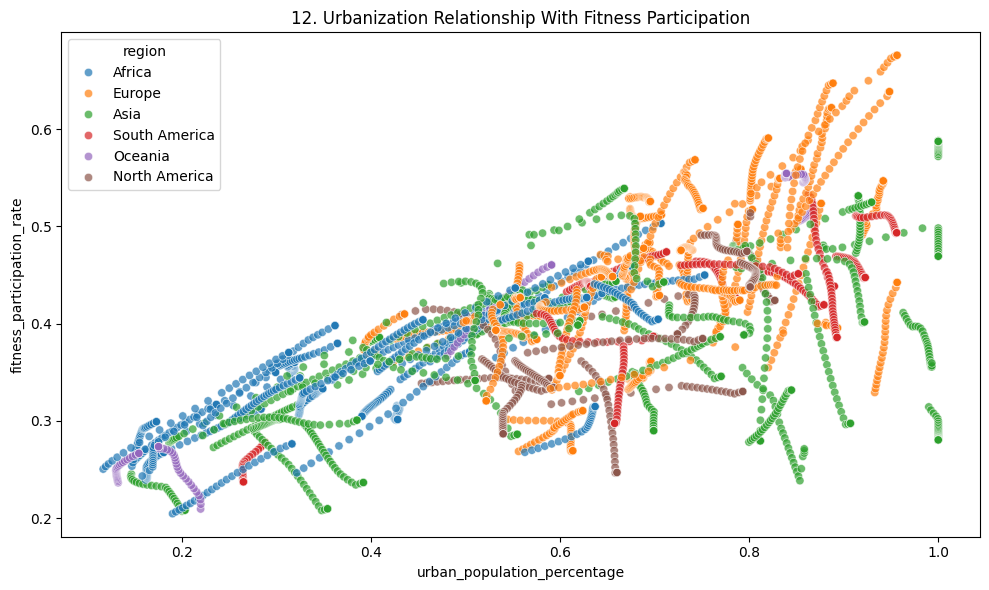

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='urban_population_percentage', y='fitness_participation_rate', hue='region', alpha=0.7)
plt.title(f'{plot_no}. Urbanization Relationship With Fitness Participation')
show_fig()
plot_no += 1

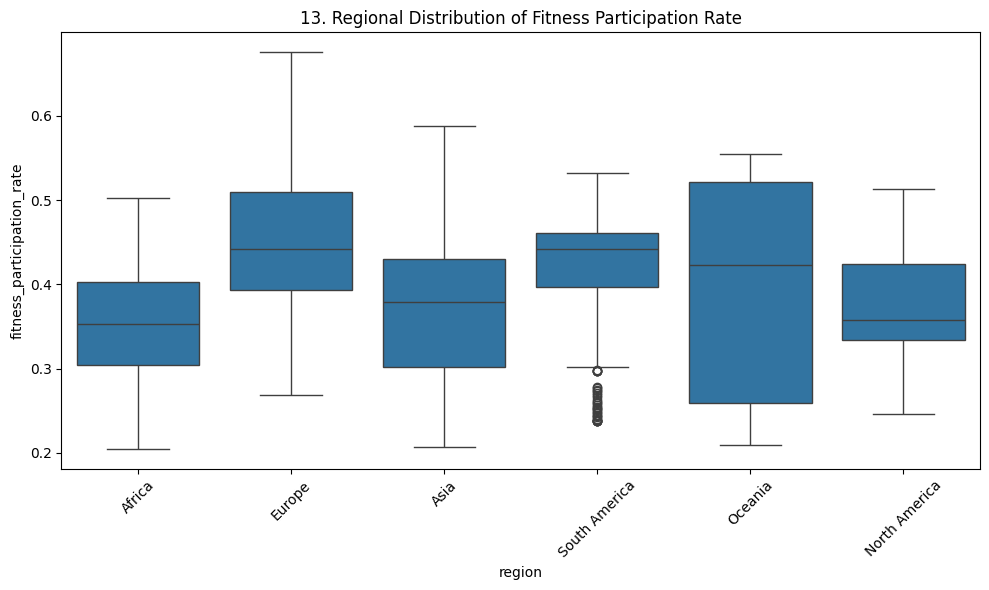

In [25]:
vfig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='region', y='fitness_participation_rate')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Regional Distribution of Fitness Participation Rate')
show_fig()
plot_no += 1

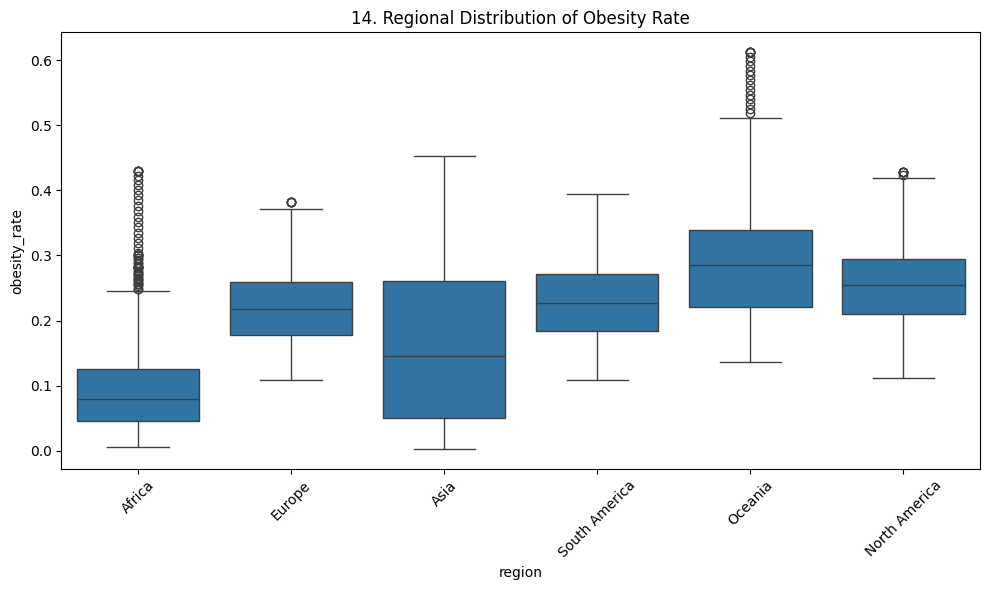

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='region', y='obesity_rate')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Regional Distribution of Obesity Rate')
show_fig()
plot_no += 1

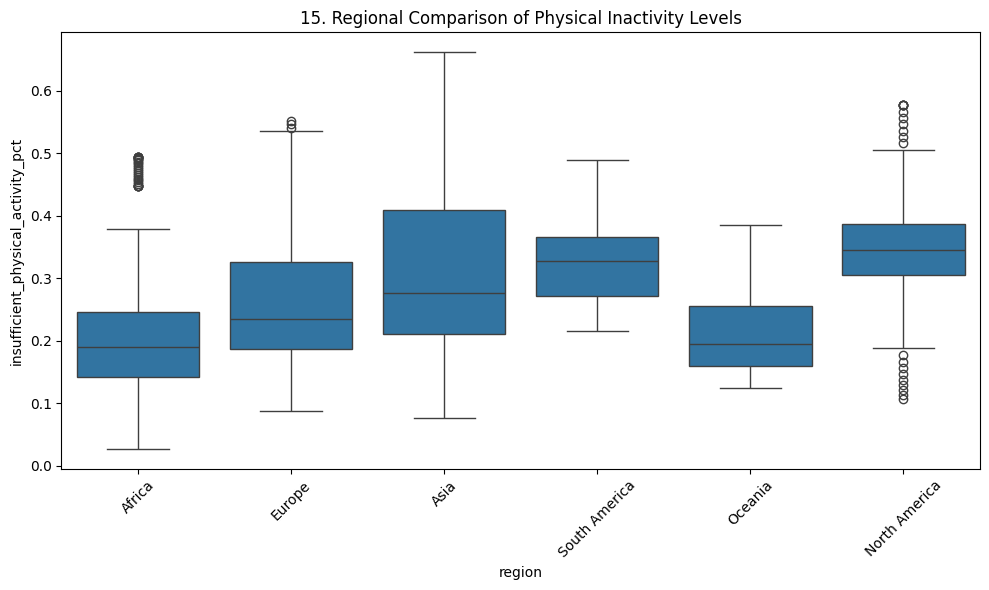

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='region', y='insufficient_physical_activity_pct')
plt.xticks(rotation=45)
plt.title(f'{plot_no}. Regional Comparison of Physical Inactivity Levels')
show_fig()
plot_no += 1

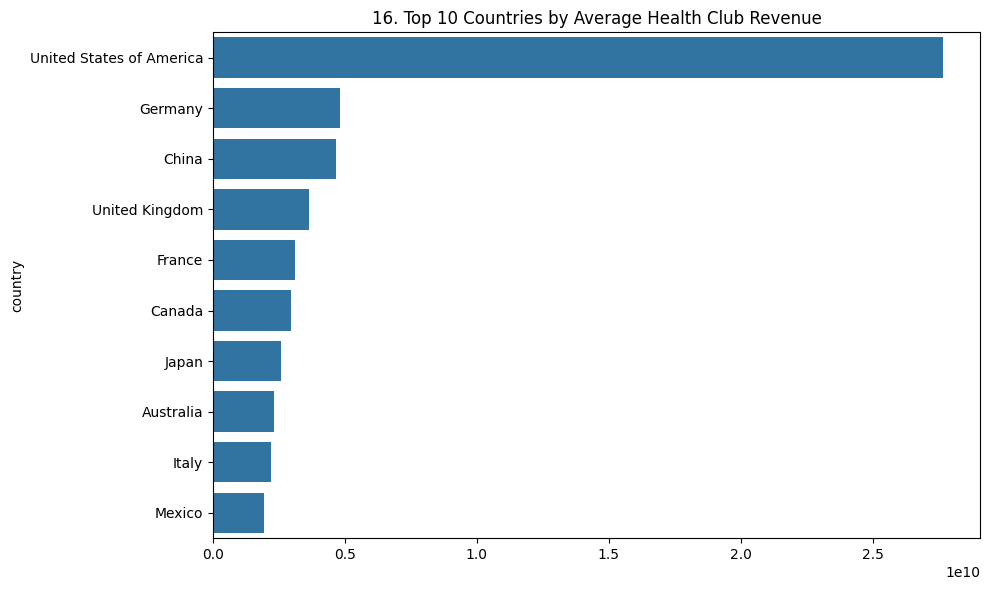

In [28]:
fig = plt.figure(figsize=(10,6))
top_revenue = df.groupby('country')['total_health_club_revenue_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_revenue.values, y=top_revenue.index)
plt.title(f'{plot_no}. Top 10 Countries by Average Health Club Revenue')
show_fig()
plot_no += 1

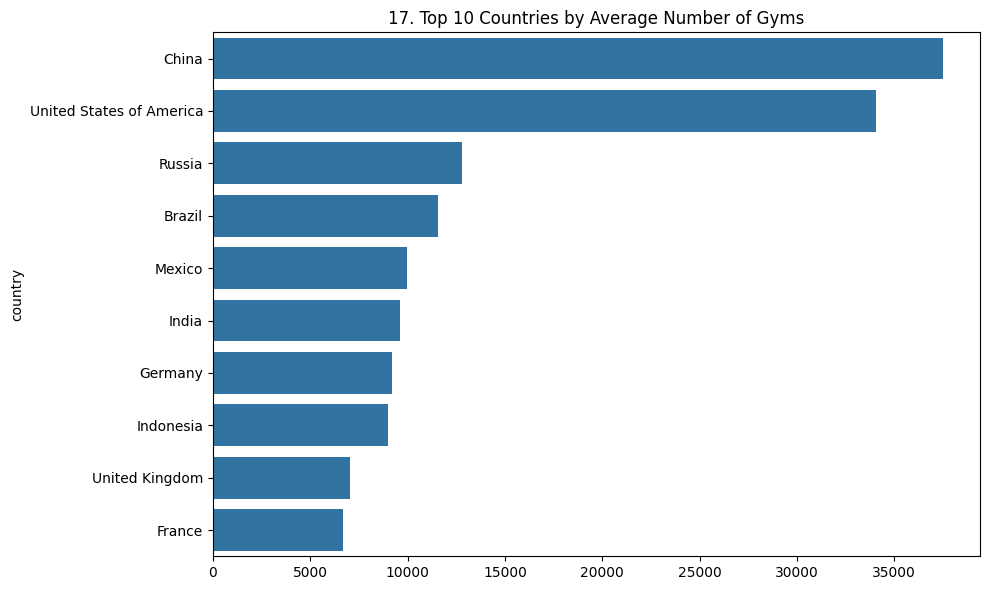

In [29]:
fig = plt.figure(figsize=(10,6))
top_gyms = df.groupby('country')['number_of_gyms'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_gyms.values, y=top_gyms.index)
plt.title(f'{plot_no}. Top 10 Countries by Average Number of Gyms')
show_fig()
plot_no += 1

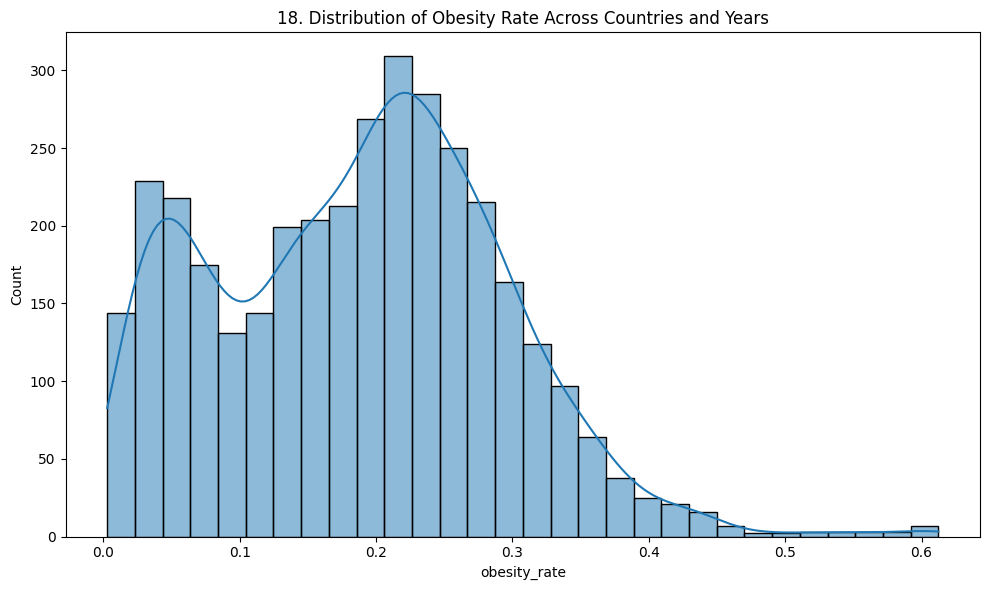

In [30]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='obesity_rate', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Obesity Rate Across Countries and Years')
show_fig()
plot_no += 1

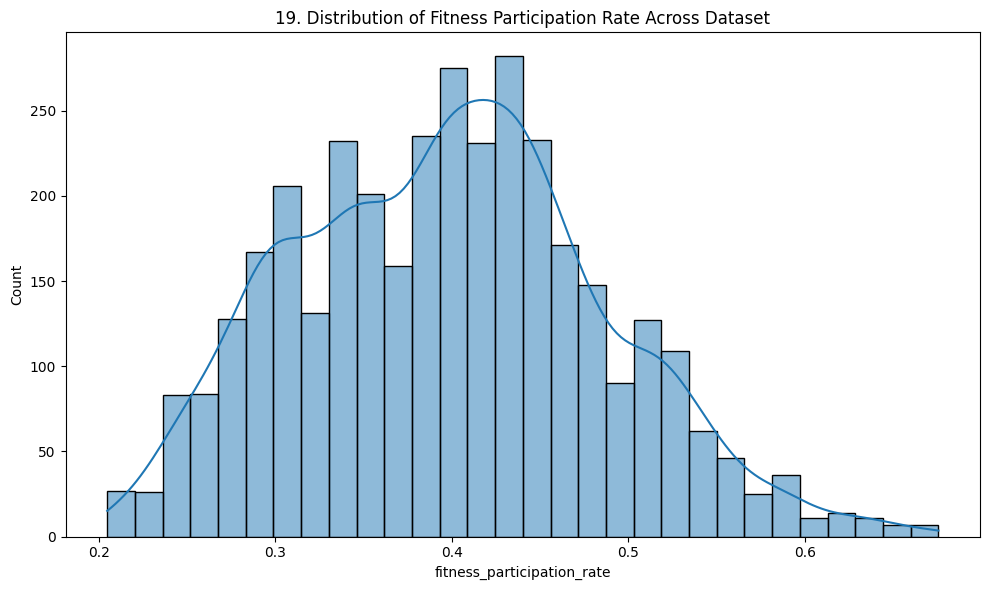

In [31]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='fitness_participation_rate', bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of Fitness Participation Rate Across Dataset')
show_fig()
plot_no += 1

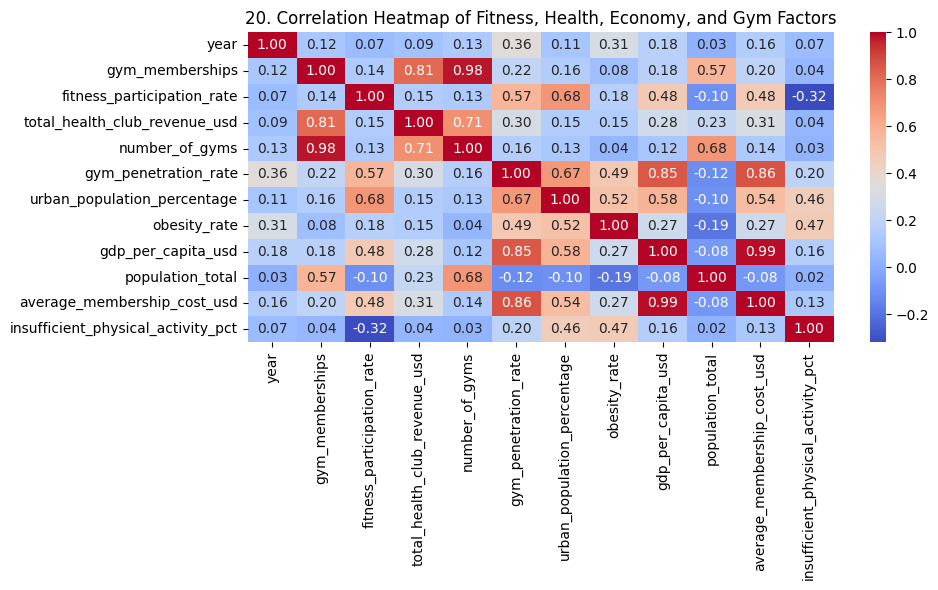

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Fitness, Health, Economy, and Gym Factors')
show_fig()
plot_no += 1

In [33]:
corr

,year,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
year,1.000000,0.124006,0.067052,0.092983,0.131607,0.358632,0.111803,0.307746,0.179311,0.026075,0.159336,0.065219
gym_memberships,0.124006,1.000000,0.143830,0.812254,0.977419,0.217177,0.156038,0.081549,0.181681,0.574954,0.202664,0.044836
fitness_participation_rate,0.067052,0.143830,1.000000,0.150313,0.129816,0.568238,0.683772,0.175159,0.483447,-0.102323,0.476616,-0.318343
total_health_club_revenue_usd,0.092983,0.812254,0.150313,1.000000,0.705429,0.300175,0.154874,0.151628,0.277418,0.228982,0.312515,0.037336
number_of_gyms,0.131607,0.977419,0.129816,0.705429,1.000000,0.161257,0.128249,0.037421,0.122128,0.681149,0.138716,0.028693
gym_penetration_rate,0.358632,0.217177,0.568238,0.300175,0.161257,1.000000,0.672900,0.493174,0.854559,-0.115408,0.862586,0.196956
urban_population_percentage,0.111803,0.156038,0.683772,0.154874,0.128249,0.672900,1.000000,0.520865,0.577835,-0.104224,0.541599,0.457595
obesity_rate,0.307746,0.081549,0.175159,0.151628,0.037421,0.493174,0.520865,1.000000,0.268480,-0.189827,0.268781,0.473558
gdp_per_capita_usd,0.179311,0.181681,0.483447,0.277418,0.122128,0.854559,0.577835,0.268480,1.000000,-0.075418,0.989220,0.162179
population_total,0.026075,0.574954,-0.102323,0.228982,0.681149,-0.115408,-0.104224,-0.189827,-0.075418,1.000000,-0.076666,0.023045


# Model Training

## Select target column

In [34]:
target = "obesity_rate"

## Create X and y

In [35]:
X = df.drop(columns=[target])
y = df[target]

## Separate numeric and categorical columns

In [36]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

## Create numeric preprocessing

In [37]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Create categorical preprocessing

In [38]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

## Combine preprocessing

In [39]:
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Create supervised model

In [40]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

## Create final pipeline

In [41]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

## Split data into train and test

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train model

In [43]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [44]:
y_pred = pipeline.predict(X_test)

## Calculate model accuracy

In [45]:
accuracy = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

## Print model performance

In [46]:
print("Model Accuracy Score (R2):", accuracy)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Model Accuracy Score (R2): 0.9534456093315866
Mean Absolute Error: 0.01757129957319034
Root Mean Squared Error: 0.02188893624769813


## Plot actual vs predicted values

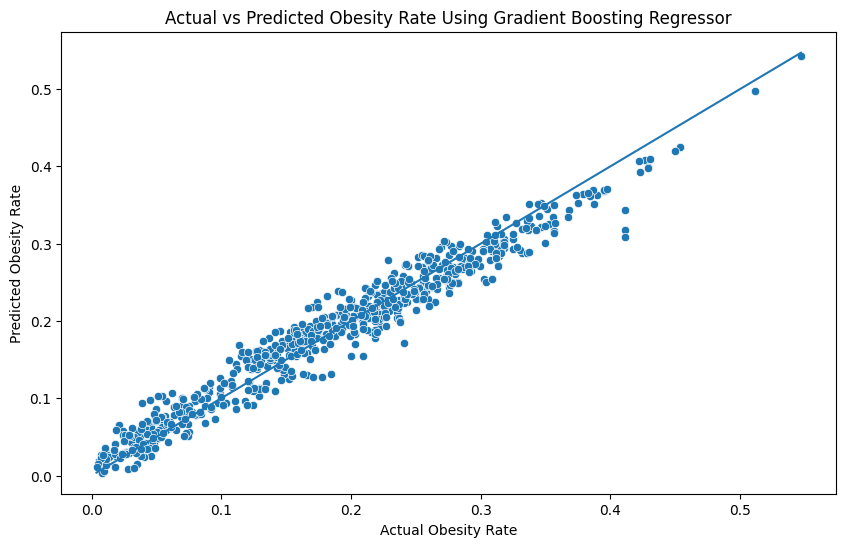

In [47]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual Obesity Rate")
plt.ylabel("Predicted Obesity Rate")
plt.title("Actual vs Predicted Obesity Rate Using Gradient Boosting Regressor")
plt.show()